## 0 - Imports 


In [23]:
# Hugging Face
from datasets import load_dataset
from transformers import pipeline, WhisperProcessor, WhisperForConditionalGeneration
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

#Tensorflow
# import tensorflow as tf

# Data Analysis
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import evaluate
# import sacrebleu


# Audio handling
import torch
import soundfile as sf
import librosa
import queue
import threading
from IPython.display import Audio


# Audio Recording
import sounddevice as sd
from scipy.io.wavfile import write


# Transcription
from jiwer import wer
from jiwer import cer
from jiwer import Compose, ToLowerCase, RemovePunctuation, RemoveMultipleSpaces, Strip

# Misc
import time
import os
import joblib
import random


## 1 - Load Datasets

In [3]:
# Streaming instead of download
def load_fleurs(lang_code, split):
    return load_dataset('google/fleurs',lang_code,split=split,streaming = True)

In [2]:
#Load the training portion of each language - takes a couple minutes for first time
fleurs_en = load_dataset("google/fleurs", "en_us", split="train[:2000]",trust_remote_code = True)
fleurs_es = load_dataset("google/fleurs", "es_419", split="train[:2000]", trust_remote_code = True)
fleurs_ja = load_dataset("google/fleurs", "ja_jp", split="train[:2000]", trust_remote_code = True)
fleurs_de = load_dataset("google/fleurs", "de_de", split="train[:2000]", trust_remote_code = True)
fleurs_fr = load_dataset("google/fleurs", "fr_fr", split="train[:2000]", trust_remote_code = True)


# Test Data
fleurs_en_test = load_dataset("google/fleurs", "en_us", split="test",trust_remote_code = True)
fleurs_es_test = load_dataset("google/fleurs", "es_419", split="test",trust_remote_code = True)
fleurs_ja_test = load_dataset("google/fleurs", "ja_jp", split="test",trust_remote_code = True)
fleurs_de_test = load_dataset("google/fleurs", "de_de", split="test", trust_remote_code = True)
fleurs_fr_test = load_dataset("google/fleurs", "fr_fr", split="test", trust_remote_code = True)


In [5]:

# print(os.environ["HF_HUB_DISABLE_BROTLI"])

# #Better Method to load
# fleurs_ko = load_fleurs('ko_kr', 'train[:2000]')
# fleurs_ch = load_fleurs("cmn_hans_cn","train[:2000]")
# fleurs_it = load_fleurs("it_it", "train[:2000]")
# fleurs_ru = load_fleurs("ru_ru", "train[:2000]")
# fleurs_ar = load_fleurs("ar_eg", "train[:2000]")

# #Test Data
# fleurs_ko_test = load_fleurs("ko_kr","test")
# fleurs_ch_test = load_fleurs("cmn_hans_cn","test")
# fleurs_it_test = load_fleurs("it_it", "test")
# fleurs_ru_test = load_fleurs("ru_ru", "test")
# fleurs_ar_test = load_fleurs("ar_eg", "test")


In [5]:
# See outputs
sample_en = fleurs_en[0]
sample_en.keys()

sample_en

{'id': 903,
 'num_samples': 108800,
 'path': 'C:\\Users\\jking36\\.cache\\huggingface\\datasets\\downloads\\extracted\\00f4c8069bdbe2061746b64297f5f7dd1af5f4ac9c3f84e1cc27006199d80190\\10004088536354799741.wav',
 'audio': {'path': 'train/10004088536354799741.wav',
  'array': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -3.15904617e-06, -3.03983688e-06, -3.27825546e-06], shape=(108800,)),
  'sampling_rate': 16000},
 'transcription': 'a tornado is a spinning column of very low-pressure air which sucks the surrounding air inward and upward',
 'raw_transcription': 'A tornado is a spinning column of very low-pressure air, which sucks the surrounding air inward and upward.',
 'gender': 1,
 'lang_id': 19,
 'language': 'English',
 'lang_group_id': 0}

## 2 - Obtain ASR Model


In [3]:
# device = 0 if torch.cuda.is_available() else -1 

device = 0 if torch.cuda.is_available() else -1


whis_sm = 'openai/whisper-small'
# whis_m = 'openai/whisper-medium'

asr = pipeline(
    'automatic-speech-recognition',
    model = whis_sm,  #small model to run quick/ medium option
    device = device,
    generate_kwargs = {'task': 'transcribe'}
)

# Or Directly import model - for transcription + detection auto

processor = WhisperProcessor.from_pretrained(whis_sm)
whisper = WhisperForConditionalGeneration.from_pretrained(whis_sm).to(device)
whisper.eval()



Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

In [7]:
#Use English sample to test asr

audio = sample_en['audio']['array']

testing = asr(audio)

print(f'Predicted Text: {testing["text"]} - Predicted Language: {testing.get("language")}')
print(f'True ENG Text: {sample_en["transcription"]} - True Language: {sample_en["language"]}')

A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


Predicted Text:  A tornado is a spinning column of very low pressure air, which sucks the surrounding air inward and upward. - Predicted Language: None
True ENG Text: a tornado is a spinning column of very low-pressure air which sucks the surrounding air inward and upward - True Language: English


## 3 - Record Audio for Model
    Function to record audio clip for Language Detection and Transcription

In [ ]:
#### RECORD AUDIO FILE .wav
def fixed_audio():
    SAMPLE_RATE = 16000
    DURATION = 15 #seconds
    OUTPUT = '../audio/recording.wav'

    print('Recording in process...')

    audio = sd.rec(
        int(DURATION * SAMPLE_RATE),
        samplerate = SAMPLE_RATE,
        channels = 1,
        dtype = np.float32
    )

    sd.wait()

    write(OUTPUT,SAMPLE_RATE,audio)
    print('Audio Recording Saved --> "recording.wav"')


Recording in process...
Audio Recording Saved --> "recording.wav"


In [ ]:
### RECORD VARIABLE LENGTH AUDIO .wav FILE
def record_audio(OUTPUT = '../audio/recording2.wav'):
    SAMPLE_RATE = 16000
    MAX_DURATION = 30 #seconds

    audio_chunks = []
    start = time.time()

    def callback(indata,frames,time_info,status):
        if status:
            print(status)
        audio_chunks.append(indata.copy())

    print('Recording in progress... (press enter to end)')

    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype=np.float32,
        callback=callback
    ):
        input() #enter to end

        if time.time() - start >= MAX_DURATION:
            print('Max Recording Duration limit reached...')

    audio = np.concatenate(audio_chunks,axis = 0)

    write(OUTPUT, SAMPLE_RATE, audio)
    print('Audio Recording Saved ----> "recording2.wav"')

record_audio()


Recording in progress... (press enter to end)
Audio Recording Saved ----> "recording2.wav"


In [ ]:
# Transcribe Audio Recording
# --> RUNTIME = 13 sec
recording, sr = librosa.load('../audio/recording2.wav',sr = 16000)
transcribed = asr(recording)
ttext = transcribed['text']
print(f"Transcription of Recording audio: {ttext}")

Transcription of Recording audio:  I am testing for Dr. Lee for my language transcription project.
[ 0.0000000e+00  0.0000000e+00 -3.0517578e-05 ...  7.3242188e-04
  8.5449219e-04  7.9345703e-04]


In [4]:
#Add mapping for whisper detection
WH_MAP = {
    'en': 'English',
    'es': 'Spanish',
    'ja': 'Japanese',
    'ch': 'Chinese',
    'ko': 'Korean',
    'de': 'German',
    'fr': 'French'
}

In [5]:
#Language transcription + Detection Function
def transcription(audio):
    recording, sr = librosa.load(audio, sr=16000)

    inputs =  processor(recording,
                   sampling_rate = sr,
                   return_tensors='pt')

    input_features = inputs['input_features'].to(device)
    
    #Detect Language
    with torch.no_grad():
        lang_prob = whisper.detect_language(input_features)
        lang_token = lang_prob.item()


        detected_lang = processor.tokenizer.convert_ids_to_tokens(lang_token)
        detected_lang = detected_lang.replace('<|', '').replace('|>', '')
                        

        #Force language into decoder
        forced_decoder_ids = processor.get_decoder_prompt_ids(
            language=detected_lang,
            task = 'transcribe'
        )

        generated_ids = whisper.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3  # optional: reduce repeating words
        )

        transcript = processor.batch_decode(
            generated_ids,
            skip_special_tokens = True
        )[0]
        
        #Language Mapping
        ln = WH_MAP[detected_lang]

    return transcript, ln


In [27]:
textt , textl = transcription('../audio/recording2.wav')
print(f"Transcription: {textt}\nLanguage: {textl}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Transcription:  I am testing for Dr. Lee, for my language transcription project
Language: English


## 4 - Basic Language Detection Model 
- Basic Classification Model trained on fleurs data
- Goal: Take in transcription of audio recording and accurately display the language
- For: The toggle between languages once we get to the translation model

In [6]:
#Create Training Data - combination of language data

#for downloaded datasets only
# def fleurs_df(dataset):
#     return pd.DataFrame({'text': dataset['transcription'],
#                          'language': dataset['language']})



#function for streaming/downloaded datasets
def fleurs_df(dataset, limit = 5000):
    rows = []

    for i, line in enumerate(dataset):
        rows.append({
            'text': line['transcription'],
            'language': line['language']
        })

        if limit is not None and i + 1 >= limit:
            break
    return pd.DataFrame(rows)

df_en = fleurs_df(fleurs_en)
df_es = fleurs_df(fleurs_es)
df_jp = fleurs_df(fleurs_ja)
df_de = fleurs_df(fleurs_de)
df_fr = fleurs_df(fleurs_fr)



data = pd.concat([df_en,df_es,df_jp
                  ,df_de,df_fr
                # ,df_ko,df_ch,df_it,df_ru,df_ar
                  ]
                  ,ignore_index=True)

data

# data.loc[data['language']=='Japanese']


,text,language
0,a tornado is a spinning column of very low-pre...,English
1,former u.s. speaker of the house newt gingrich...,English
2,the island was first inhabited by the taínos a...,English
3,these nerve impulses can be sent so quickly th...,English
4,on september 24 1759 arthur guinness signed a ...,English
...,...,...
9995,le programme a démarré à 20 h 30 heure locale ...,French
9996,cependant une source ayant connaissance de l'e...,French
9997,alexeï leonov également connu sous le nom de «...,French
9998,peter lenz un pilote de moto de 13 ans est mor...,French


In [11]:
### IMPORTANT - Adding shortened data pieces from existing data to the training set to help with translating 1-3 word inputs!

# FOR ENGLISH/SPANISH/ETC
rng = np.random.RandomState(42) #consistency in randomess

def short_text(text, minimum = 2, maximum = 4, samples = 1):
    tokens = text.split()

    if len(tokens) <= maximum:
        return [text]
    
    short = []
    for x in range(samples):
        rand_len = rng.randint(minimum,maximum)
        begin = rng.randint(0,len(tokens)-rand_len)
        short.append(' '.join(tokens[begin:begin+rand_len]))
    
    return short

##################################################################
def shorten_text(df, language, sh_list = None): 
    if sh_list is None: #crucial for allowing list to be unique each call
        sh_list = []
    for row in df['text']:
        # sh_list.append(row)
        # print(row)
        
        for sh in short_text(row):
            sh_list.append({
                'text': sh,
                'language': language
            })
    return sh_list

short_en = shorten_text(df_en, df_en['language'][0]) #[0] = the correct language for the text

short_es = shorten_text(df_es, df_es['language'][0])
short_fr = shorten_text(df_fr, df_fr['language'][0])
short_de = shorten_text(df_de, df_de['language'][0])


print(f'Length of English Shortened: {len(short_en)} + random example \n {short_en[0]}') #first example
print(f'Length of Spanish Shortened: {len(short_es)} + random example \n {short_es[0]}') #first example [0]
print(f'Length of French Shortened: {len(short_fr)} + random example \n {short_fr[0]}') #first example [0]
print(f'Length of German Shortened: {len(short_de)} + random example \n {short_de[0]}') #first example [0]



# proof of concept
# taco = 'hello this is a test woahh i am going to try and have lots of tokens within this sentence'

# print(taco.split())

# sh = []
# for x in range(1):
#     leng = random.randint(2,3)
#     st = random.randint(0,len(taco.split())-leng)
#     sh.append(" ".join(taco.split()[st:st+leng]))
# print(sh)

Length of English Shortened: 2000 + random example 
 {'text': 'a spinning', 'language': 'English'}
Length of Spanish Shortened: 2000 + random example 
 {'text': 'los murales', 'language': 'Spanish'}
Length of French Shortened: 2000 + random example 
 {'text': 'terrestre vers 5', 'language': 'French'}
Length of German Shortened: 2000 + random example 
 {'text': 'der regel', 'language': 'German'}


In [12]:
### FOR JP/KO/CH

def shorten_jp(text, min_chars=3, max_chars=6):
    if len(text) <= max_chars:
        return text
    
    start = rng.randint(0,len(text) - max_chars)
    length = rng.randint(min_chars, max_chars)
    return text[start:start+length]

short_jp = []

for text in df_jp['text']:
    short_jp.append({
        'text': shorten_jp(text),
        'language': 'Japanese'     #hard coded - could do df_jp['language'][0] for when new languages added and make a function instead
    })

print(f'Length of Japanese Shortened: {len(short_jp)} + random example \n {short_jp[0]}')
print(f'Length of Japanese Shortened: {len(short_jp)} + random example \n {short_jp[1]}')



Length of Japanese Shortened: 2000 + random example 
 {'text': 'を負っ', 'language': 'Japanese'}
Length of Japanese Shortened: 2000 + random example 
 {'text': '自足農業', 'language': 'Japanese'}


In [13]:
### ADD NEW SHORTENED DATA ROWS INTO MAIN DATA FOR TRAINING

df_short_en = pd.DataFrame(short_en)
df_short_es = pd.DataFrame(short_es)
df_short_jp = pd.DataFrame(short_jp)
df_short_fr = pd.DataFrame(short_fr)
df_short_de = pd.DataFrame(short_de)


print(df_short_jp.head())

data2 = pd.concat([data,df_short_en, df_short_es, df_short_jp, df_short_fr,df_short_de],ignore_index = True)

data2 = data2.sample(frac=1,random_state=42).reset_index(drop=True)
print(f'Original Training Data Counts --> {data["language"].value_counts(0)}')
print(f'New Training Data Counts --> {data2["language"].value_counts(0)}')

    text  language
0    を負っ  Japanese
1   自足農業  Japanese
2    された  Japanese
3    海外で  Japanese
4  ンを投与す  Japanese
Original Training Data Counts --> language
English     2000
Spanish     2000
Japanese    2000
German      2000
French      2000
Name: count, dtype: int64
New Training Data Counts --> language
English     4000
Spanish     4000
French      4000
German      4000
Japanese    4000
Name: count, dtype: int64


In [11]:
#Train/Test Split

X = data['text']
y= data['language']

# X = data2['text']
# y = data2['language']

X_train, X_dev, y_train, y_dev = train_test_split(X,y,test_size=.2,random_state = 42, stratify = y)


In [12]:
# Vectorizer - maybe go back and save on joblib**
vectorized = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2,5),
    min_df=2,
    max_features=20000
)

X_train_v = vectorized.fit_transform(X_train)
X_dev_v = vectorized.transform(X_dev)

X_train_v


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3292836 stored elements and shape (11096, 20000)>

In [13]:
# Random Forest Classifier
def Detection(X_train, X_dev, y_train, y_dev,  model_path = '../models/detection.pkl'):
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    model.fit(X_train,y_train)
    #Predictions
    y_pred = model.predict(X_dev)
    prob = model.predict_proba(X_dev)[:,1]

    #Scoring - F1/accuracy
    f1 = f1_score(y_dev,y_pred, average= 'macro')
    accuracy = accuracy_score(y_dev,y_pred)
    print(f'F1 Score: {f1:.4f} ---- Accuracy: {accuracy:.4f}')
    print(f'Classification Report: \n {classification_report(y_dev,y_pred)}')

    #Save Model
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")

    return model


In [14]:
# Run Training Model 

Detection(X_train_v,X_dev_v, y_train, y_dev)


F1 Score: 0.9996 ---- Accuracy: 0.9996
Classification Report: 
               precision    recall  f1-score   support

     English       1.00      1.00      1.00       520
      French       1.00      1.00      1.00       639
      German       1.00      1.00      1.00       597
    Japanese       1.00      1.00      1.00       459
     Spanish       1.00      1.00      1.00       559

    accuracy                           1.00      2774
   macro avg       1.00      1.00      1.00      2774
weighted avg       1.00      1.00      1.00      2774

Model saved to ../models/detection.pkl


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
# Random Forest Classifier - with input as data/data2
def Detection2(data,model_path = '../models/detectionv2.pkl'):

    X = data['text']
    y = data['language']
    X_train, X_dev, y_train, y_dev = train_test_split(X,y,test_size=.2,random_state = 42, stratify = y)

    # Vectorizer - maybe go back and save on joblib**
    vectorized2 = TfidfVectorizer(
        analyzer='char',
        ngram_range=(3,6),
        min_df=2,
        max_features=20000
    )

    X_train_v = vectorized2.fit_transform(X_train)
    X_dev_v = vectorized2.transform(X_dev)


    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    model.fit(X_train_v,y_train)
    #Predictions
    y_pred = model.predict(X_dev_v)
    prob = model.predict_proba(X_dev_v)[:,1]

    #Scoring - F1/accuracy
    f1 = f1_score(y_dev,y_pred, average= 'macro')
    accuracy = accuracy_score(y_dev,y_pred)
    print(f'F1 Score: {f1:.4f} ---- Accuracy: {accuracy:.4f}')
    print(f'Classification Report: \n {classification_report(y_dev,y_pred)}')

    #Save Model
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")

    return model


In [16]:
# Run Training Model on New Data (appended short tokens)

Detection2(data2)

F1 Score: 0.9446 ---- Accuracy: 0.9436
Classification Report: 
               precision    recall  f1-score   support

     English       0.95      0.92      0.93      1041
      French       0.93      0.92      0.93      1277
      German       0.97      0.94      0.96      1195
    Japanese       0.95      1.00      0.97       917
     Spanish       0.92      0.94      0.93      1118

    accuracy                           0.94      5548
   macro avg       0.94      0.95      0.94      5548
weighted avg       0.94      0.94      0.94      5548

Model saved to ../models/detectionv2.pkl


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
# Predict Function on Audio Transcription

def predict_detect(text, lang, model_path = '../models/detection.pkl'):
    model = joblib.load(model_path)
    input = vectorized.transform([text])

    result = model.predict(input)[0]
    pred = model.predict_proba(input)[0]
    pred2 = [str(x) for x in pred] #forces the output to ONLY be prediction confidence - no float.np etc

    conf = dict(zip(model.classes_,pred2))
    conf2 = {} #sorted confidence descending
    #while loop to get max values first - sort
    while conf:
        max_key = max(conf, key=conf.get)
        max_value = conf[max_key]

        conf2[max_key] = max_value

        del conf[max_key]
    


    y_true = np.array([lang])
    y_pred = np.array([result])
    acc = accuracy_score(y_true, y_pred)
    return result, conf2


def predict_detect2(text, lang, model_path = '../models/detectionv2.pkl'):
    model = joblib.load(model_path)
    input = vectorized.transform([text])

    result = model.predict(input)[0]
    pred = model.predict_proba(input)[0]
    pred2 = [str(x) for x in pred] #forces the output to ONLY be prediction confidence - no float.np etc

    conf = dict(zip(model.classes_,pred2))
    conf2 = {} #sorted confidence descending
    #while loop to get max values first - sort
    while conf:
        max_key = max(conf, key=conf.get)
        max_value = conf[max_key]

        conf2[max_key] = max_value

        del conf[max_key]
    


    y_true = np.array([lang])
    y_pred = np.array([result])
    acc = accuracy_score(y_true, y_pred)
    return result, conf2




In [18]:
# TEST DATA

df_en_test = fleurs_df(fleurs_en_test)
df_es_test = fleurs_df(fleurs_es_test)
df_jp_test = fleurs_df(fleurs_ja_test)
df_fr_test = fleurs_df(fleurs_fr_test)
df_de_test = fleurs_df(fleurs_de_test)

test_data = pd.concat([df_en_test,df_es_test,df_jp_test, df_fr_test, df_de_test],ignore_index=True)

test_data

,text,language
0,however due to the slow communication channels...,English
1,all nouns alongside the word sie for you alway...,English
2,to the north and within easy reach is the roma...,English
3,the cabbage juice changes color depending on h...,English
4,many people don't think about them as dinosaur...,English
...,...,...
3738,die klang und lichtshow bei den pyramiden ist ...,German
3739,der kalifornische gouverneur arnold schwarzene...,German
3740,infolgedessen sind zwei fischarten ausgestorbe...,German
3741,da sie sich in den extremen tropen und nur ein...,German


In [19]:
# Predict on Test Data
# X_test = test_data['text']
# y_test = test_data['language']


# X_test_vec = vectorized.transform(X_test)

# model_rf = joblib.load('detection.pkl')

# y_test_pred = model_rf.predict(X_test_vec)

# print(f'Test Data Performance \n Accuracy: {accuracy_score(y_test,y_test_pred)}')
# print(f'\n {classification_report(y_test,y_test_pred)}')


# Predict on Test Data - model 2
X_test = test_data['text']
y_test = test_data['language']


X_test_vec = vectorized.transform(X_test)

model_rf = joblib.load('../models/detectionv2.pkl')

y_test_pred = model_rf.predict(X_test_vec)

print(f'Test Data Performance \n Accuracy: {accuracy_score(y_test,y_test_pred)}')
print(f'\n {classification_report(y_test,y_test_pred)}')



Test Data Performance 
 Accuracy: 0.2989580550360673

               precision    recall  f1-score   support

     English       0.10      0.06      0.08       647
      French       0.14      0.11      0.12       676
      German       0.21      0.37      0.27       862
    Japanese       0.60      0.96      0.74       650
     Spanish       0.21      0.07      0.10       908

    accuracy                           0.30      3743
   macro avg       0.25      0.31      0.26      3743
weighted avg       0.25      0.30      0.25      3743



In [20]:
# Using predict Method on Audio Transcription

language, prob = predict_detect('hola como estas por favor', 'Spanish') #basic str example
language2, prob2 = predict_detect2('hola como estas por favor', 'Spanish') #New Trained Model 

print(f'Basic String Example: {language} ---> New Model: {language2}')
print('\n', prob, 'New Model ---->', prob2)


language, prob = predict_detect(ttext, 'English')
language2, prob2 = predict_detect2(ttext, 'English') #New Trained Model

print(f'\n Audio Recording Transcription Detected Language: {language} ---> New Model: {language2}')
print('\n', prob, 'New Model ---->', prob2)


Basic String Example: Spanish ---> New Model: Japanese

 {'Spanish': '0.55', 'Japanese': '0.17', 'English': '0.13', 'French': '0.09', 'German': '0.06'} New Model ----> {'Japanese': '0.4868810352160365', 'German': '0.21053838235181835', 'English': '0.13', 'French': '0.12186744488514524', 'Spanish': '0.05071313754700009'}

 Audio Recording Transcription Detected Language: English ---> New Model: English

 {'English': '0.47', 'French': '0.22', 'German': '0.19', 'Spanish': '0.07', 'Japanese': '0.05'} New Model ----> {'English': '0.45', 'German': '0.210240667282237', 'Japanese': '0.2087299790535719', 'French': '0.0707238781042557', 'Spanish': '0.06030547555993528'}


Average performance - will struggle on shorter text strings


## 5 - Advanced CNN Language Detection Model
    - Convolution Neural Network to improve accuracy of language detections
    - Provide higher accuracy amongst similar languages

In [21]:
# Separate Data(text,language) into their own lists
texts = data['text'].to_list()
labels = data['language'].to_list()

#Test Data
X_test_text = test_data['text'].to_list()
y_test_labels = test_data['language'].to_list()

In [42]:
#Tokenizing text data
max_vocab = 20000 #maximum amount of tokens (char) stored in tokenizer
max_len = 200 #max amount of tokens (char) within a sequence of input

# tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=max_vocab,oov_token="<UNK>") #no spaces in japanese made this not work, too many UNK
tokenizer = tf.keras.preprocessing.text.Tokenizer(char_level=True,lower = False)



tokenizer.fit_on_texts(texts)

X = tokenizer.texts_to_sequences(texts) #maps token to int to max_vocab
X = tf.keras.preprocessing.sequence.pad_sequences(X,maxlen=max_len,padding='post') #pad input if less than 200 characters

X_test_seq = tokenizer.texts_to_sequences(X_test_text)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test_seq,maxlen=max_len,padding='post')


In [23]:
#Label Encoding Target Variable -> Language
label_map = {0: 'English', 1: 'French', 2: 'German', 3: 'Japanese', 4: 'Spanish'} #adjust when new languages are added

Lencoder = LabelEncoder()
y = Lencoder.fit_transform(labels)
y_test = Lencoder.transform(y_test_labels)

for x, label in enumerate(Lencoder.classes_):
    print(f'{x} ---> {label}')

0 ---> English
1 ---> French
2 ---> German
3 ---> Japanese
4 ---> Spanish


In [24]:
# CONVOLUTIONAL NEURAL NETWORK

def cnn_detect(X,y,max_len, max_vocab,model_path = '../models/cnn_detect.keras'):

    multiclass_num = len(set(y))
    embed_dim = 128


    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(max_len,)),
        tf.keras.layers.Embedding(input_dim = max_vocab, output_dim = embed_dim, input_length = max_len),
        tf.keras.layers.Conv1D(filters = 128, kernel_size = 7, activation = 'relu'), #larger kernel size to detect more characters at once - n-grams - helps with analyzing language
        tf.keras.layers.GlobalMaxPooling1D(),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dropout(.5),
        tf.keras.layers.Dense(
            units = multiclass_num,
            activation = 'softmax')])

    model.compile(
        optimizer = tf.keras.optimizers.Adam(.001),
        loss = tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics = ['accuracy']
    )

    # Fit Model

    early_stop = tf.keras.callbacks.EarlyStopping(monitor = 'accuracy', patience=3, mode = 'max', restore_best_weights=True) #stop epochs once performance does not improve 3 times in a row
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='accuracy',
        factor = .4,
        patience = 3,
        mode = 'max',
        min_lr = .0002,
        verbose = 1
    )

    X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=.15, random_state=42,shuffle=True)

    history = model.fit(
        X_train,y_train,
        batch_size = 32,
        epochs = 15,
        validation_data = (X_val,y_val),
        callbacks = [early_stop,reduce_lr,
                     tf.keras.callbacks.ModelCheckpoint(
                         filepath = model_path,
                         monitor = 'accuracy',
                         mode = 'max',
                         save_best_only = True
                     )])
    
    return model, history
    
    

In [25]:
# CONVOLUTIONAL NEURAL NETWORK V2 - Addition of Short Token Training Data
def cnn_detect2(data,model_path = '../models/cnn_detect2.keras'): 
    # Separate Data(text,language) into their own lists
    texts = data['text'].to_list()
    labels = data['language'].to_list()

    #Test Data
    X_test_text = test_data['text'].to_list()
    y_test_labels = test_data['language'].to_list()


    #Tokenizing text data
    max_vocab = 20000 #maximum amount of tokens (char) stored in tokenizer
    max_len = 200 #max amount of tokens (char) within a sequence of input

    # tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=max_vocab,oov_token="<UNK>") #no spaces in japanese made this not work, too many UNK
    tokenizer = tf.keras.preprocessing.text.Tokenizer(char_level=True,lower = False)

    tokenizer.fit_on_texts(texts)

    X = tokenizer.texts_to_sequences(texts) #maps token to int to max_vocab
    X = tf.keras.preprocessing.sequence.pad_sequences(X,maxlen=max_len,padding='post') #pad input if less than 200 characters

    X_test_seq = tokenizer.texts_to_sequences(X_test_text)
    X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test_seq,maxlen=max_len,padding='post')


    #Label Encoding Target Variable -> Language
    label_map = {0: 'English', 1: 'Japanese', 2: 'Spanish'} #adjust when new languages are added

    Lencoder = LabelEncoder()
    y = Lencoder.fit_transform(labels)
    y_test = Lencoder.transform(y_test_labels)

    for x, label in enumerate(Lencoder.classes_):
        print(f'{x} ---> {label}')



    multiclass_num = len(set(y))
    embed_dim = 128


    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(max_len,)),
        tf.keras.layers.Embedding(input_dim = max_vocab, output_dim = embed_dim, input_length = max_len),
        tf.keras.layers.Conv1D(filters = 128, kernel_size = 7, activation = 'relu'), #larger kernel size to detect more characters at once - n-grams - helps with analyzing language
        tf.keras.layers.GlobalMaxPooling1D(),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dropout(.5),
        tf.keras.layers.Dense(
            units = multiclass_num,
            activation = 'softmax')])

    model.compile(
        optimizer = tf.keras.optimizers.Adam(.001),
        loss = tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics = ['accuracy']
    )

    # Fit Model

    early_stop = tf.keras.callbacks.EarlyStopping(monitor = 'accuracy', patience=3, mode = 'max', restore_best_weights=True) #stop epochs once performance does not improve 3 times in a row
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='accuracy',
        factor = .4,
        patience = 3,
        mode = 'max',
        min_lr = .0002,
        verbose = 1
    )

    X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=.15, random_state=42,shuffle=True)

    history = model.fit(
        X_train,y_train,
        batch_size = 32,
        epochs = 15,
        validation_data = (X_val,y_val),
        callbacks = [early_stop,reduce_lr,
                     tf.keras.callbacks.ModelCheckpoint(
                         filepath = model_path,
                         monitor = 'accuracy',
                         mode = 'max',
                         save_best_only = True
                     )])
    
    return model, history
    
    


Epoch 1/15


369/369 [==============================] - 18s 46ms/step - loss: 0.3033 - accuracy: 0.8959 - val_loss: 0.0048 - val_accuracy: 0.9981 - lr: 0.0010
Epoch 2/15
369/369 [==============================] - 16s 44ms/step - loss: 0.0172 - accuracy: 0.9964 - val_loss: 0.0018 - val_accuracy: 0.9995 - lr: 0.0010
Epoch 3/15
369/369 [==============================] - 12s 33ms/step - loss: 0.0106 - accuracy: 0.9975 - val_loss: 0.0017 - val_accuracy: 0.9995 - lr: 0.0010
Epoch 4/15
369/369 [==============================] - 11s 29ms/step - loss: 0.0066 - accuracy: 0.9984 - val_loss: 0.0011 - val_accuracy: 0.9995 - lr: 0.0010
Epoch 5/15
369/369 [==============================] - 10s 28ms/step - loss: 0.0091 - accuracy: 0.9974 - val_loss: 0.0012 - val_accuracy: 0.9990 - lr: 0.0010
Epoch 6/15
369/369 [==============================] - 12s 31ms/step - loss: 0.0035 - accuracy: 0.9992 - val_loss: 3.8289e-04 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/15
369/369 [==============================]

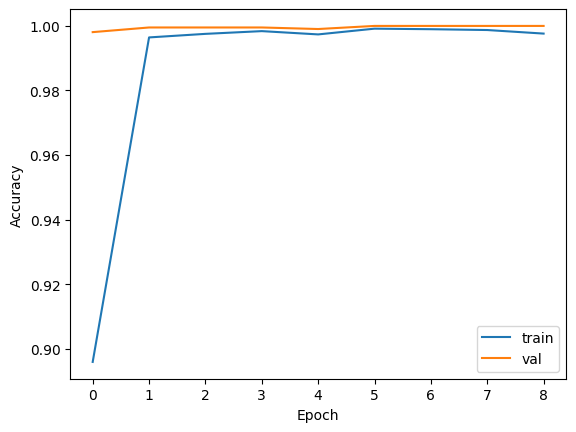

In [26]:
# Train Model and Evaluate

model,history = cnn_detect(X,y,max_len,max_vocab)

plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()



Overfitted a bit for sure as of now (Just English,Spanish,Japanese) - but is working well during my own individual testing, will be interesting to see how it works after including more languages

0 ---> English
1 ---> French
2 ---> German
3 ---> Japanese
4 ---> Spanish
Epoch 1/15
737/737 [==============================] - 17s 23ms/step - loss: 0.4028 - accuracy: 0.8504 - val_loss: 0.1732 - val_accuracy: 0.9363 - lr: 0.0010
Epoch 2/15
737/737 [==============================] - 20s 27ms/step - loss: 0.1569 - accuracy: 0.9461 - val_loss: 0.1197 - val_accuracy: 0.9584 - lr: 0.0010
Epoch 3/15
737/737 [==============================] - 20s 28ms/step - loss: 0.1213 - accuracy: 0.9600 - val_loss: 0.1151 - val_accuracy: 0.9575 - lr: 0.0010
Epoch 4/15
737/737 [==============================] - 32s 43ms/step - loss: 0.0978 - accuracy: 0.9682 - val_loss: 0.1071 - val_accuracy: 0.9615 - lr: 0.0010
Epoch 5/15
737/737 [==============================] - 36s 48ms/step - loss: 0.0764 - accuracy: 0.9744 - val_loss: 0.1229 - val_accuracy: 0.9625 - lr: 0.0010
Epoch 6/15
737/737 [==============================] - 35s 48ms/step - loss: 0.0710 - accuracy: 0.9775 - val_loss: 0.1043 - val_accuracy: 0.96

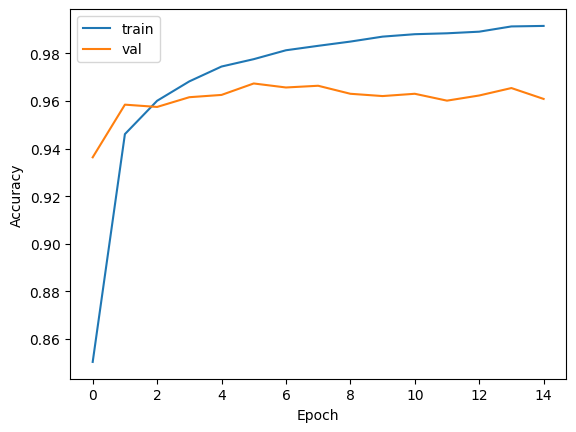

In [27]:
# Train Model and Evaluate - on Condensed CNN

model,history = cnn_detect2(data2)

plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()


In [28]:
#PREDICT on Test Data
model_cnn = tf.keras.models.load_model('../models/cnn_detect2.keras')

y_test_prob = model_cnn.predict(X_test)
y_test_pred = np.argmax(y_test_prob,axis=1)

print(classification_report(y_test,y_test_pred,target_names=Lencoder.classes_))
print(f'\n\n Confusion Matrix: \n {confusion_matrix(y_test,y_test_pred)}')

loss, cnn_accuracy = model_cnn.evaluate(X_test,y_test)

print(f'\n Accuracy: \n {cnn_accuracy}')

117/117 [==============================] - 1s 5ms/step
              precision    recall  f1-score   support

     English       1.00      1.00      1.00       647
      French       1.00      1.00      1.00       676
      German       1.00      1.00      1.00       862
    Japanese       1.00      1.00      1.00       650
     Spanish       1.00      1.00      1.00       908

    accuracy                           1.00      3743
   macro avg       1.00      1.00      1.00      3743
weighted avg       1.00      1.00      1.00      3743



 Confusion Matrix: 
 [[647   0   0   0   0]
 [  2 674   0   0   0]
 [  0   0 862   0   0]
 [  0   0   0 650   0]
 [  0   3   0   0 905]]
117/117 [==============================] - 1s 6ms/step - loss: 0.0061 - accuracy: 0.9987

 Accuracy: 
 0.9986642003059387


In [29]:
# PREDICT for Final Results

def cnn_predict(text, model_path = '../models/cnn_detect.keras'):
    model = tf.keras.models.load_model(model_path)
    seq = tokenizer.texts_to_sequences([text])
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq,maxlen=max_len, padding = 'post')
    prob = model.predict(padded)[0] #probabilities
    pred_idx = prob.argmax() #index of prediction label

    conf = {label_map[i]: round(float(prob[i]),5) for i in range(len(prob))}
    conf2 = {} #sorted confidence descending
    #while loop to get max values first - sort
    while conf:
        max_key = max(conf, key=conf.get)
        max_value = conf[max_key]

        conf2[max_key] = max_value

        del conf[max_key]

    return label_map[pred_idx], round(float(prob[pred_idx]),3), conf2

############# Model 2 - New Training Data ##################

def cnn_predict2(text, model_path = '../models/cnn_detect2.keras'):
    model = tf.keras.models.load_model(model_path)
    seq = tokenizer.texts_to_sequences([text])
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq,maxlen=max_len, padding = 'post')
    prob = model.predict(padded)[0] #probabilities
    pred_idx = prob.argmax() #index of prediction label

    conf = {label_map[i]: round(float(prob[i]),5) for i in range(len(prob))}
    conf2 = {} #sorted confidence descending
    #while loop to get max values first - sort
    while conf:
        max_key = max(conf, key=conf.get)
        max_value = conf[max_key]

        conf2[max_key] = max_value

        del conf[max_key]

    return label_map[pred_idx], round(float(prob[pred_idx]),3), conf2


In [30]:
# result = cnn_predict('hello world') # Eng -> .96 Jp -> .0 Sp -> .06
result_es = cnn_predict('hola como estas mi amigo') # 5 tokens 
result_es2 = cnn_predict('mi amigo') # 2 tokens 
result_es3 = cnn_predict('derecha') # 1 token


result_b = cnn_predict2('hola como estas mi amigo')
result_b2 = cnn_predict2('mi amigo')
result_b3 = cnn_predict2('derecha')


print(f'Language Predicted: {result_es[0]} - with a Confidence of {result_es[1]} \n\n All Classes Probabilities \n {result_es[2]}\n ---> New Model \n {result_b[2]}\n')
print(f'Language Predicted: {result_es2[0]} - with a Confidence of {result_es2[1]} \n\n All Classes Probabilities \n {result_es2[2]}\n ---> New Model \n {result_b2[2]}\n')
print(f'Language Predicted: {result_es3[0]} - with a Confidence of {result_es3[1]} \n\n All Classes Probabilities \n {result_es3[2]}\n ---> New Model \n {result_b3[2]}\n')



1/1 [==============================] - 0s 47ms/step
Language Predicted: Spanish - with a Confidence of 0.973 

 All Classes Probabilities 
 {'Spanish': 0.9732, 'English': 0.02678, 'French': 2e-05, 'German': 0.0, 'Japanese': 0.0}
 ---> New Model 
 {'Spanish': 1.0, 'English': 0.0, 'French': 0.0, 'German': 0.0, 'Japanese': 0.0}

Language Predicted: Spanish - with a Confidence of 0.987 

 All Classes Probabilities 
 {'Spanish': 0.98653, 'English': 0.01284, 'Japanese': 0.00052, 'French': 6e-05, 'German': 4e-05}
 ---> New Model 
 {'Spanish': 0.9969, 'German': 0.0027, 'French': 0.00031, 'English': 8e-05, 'Japanese': 1e-05}

Language Predicted: German - with a Confidence of 0.92 

 All Classes Probabilities 
 {'German': 0.91987, 'Spanish': 0.06774, 'English': 0.01174, 'Japanese': 0.00057, 'French': 8e-05}
 ---> New Model 
 {'Spanish': 0.70471, 'German': 0.29251, 'French': 0.00276, 'English': 1e-05, 'Japanese': 0.0}



*** As of now it is important to have an input of atleast 3 words for accurate predicting, the more the better!

*** Post Data Manipulation - Added shortened data points to each language in the training and now correctly classifies short input texts!!!


In [63]:
# Testing Detection
td = cnn_predict2('Practice')
print(f'Language Predicted: {td[0]} - with a Confidence of {td[1]} \n\n All Classes Probabilities \n {td[2]}')

1/1 [==============================] - 0s 45ms/step
Language Predicted: English - with a Confidence of 0.996 

 All Classes Probabilities 
 {'English': 0.99554, 'French': 0.00403, 'Spanish': 0.00043, 'German': 0.0, 'Japanese': 0.0}


In [32]:
# Result from audio transcription

result = cnn_predict2(ttext)
print(f'Language Predicted: {result[0]} - with a Confidence of {result[1]} \n\n All Classes Probabilities \n {result[2]}\n\n{ttext}')

1/1 [==============================] - 0s 43ms/step
Language Predicted: English - with a Confidence of 1.0 

 All Classes Probabilities 
 {'English': 1.0, 'French': 0.0, 'German': 0.0, 'Japanese': 0.0, 'Spanish': 0.0}

 I am testing for Dr. Lee for my language transcription project.


## 6 - Obtain Translation Model
- Set up Translation Model
- Test it on our transcribed text
- Explore unique outputs for website tool

In [6]:
# Load Google MT5-small translation model

translation_model_name =  'facebook/nllb-200-distilled-600M' # for fine tuning myself  -- > 'google/mt5-base'

tokenizer_nllb = AutoTokenizer.from_pretrained(translation_model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(translation_model_name).to(device)

model.eval()

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


M2M100ForConditionalGeneration(
  (model): M2M100Model(
    (shared): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-11): 12 x M2M100EncoderLayer(
          (self_attn): M2M100Attention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
       

In [7]:
# LANGUAGE MAPPING FOR NLLB CODING - add as more languages implemented

LANG_NNLB_MAP = {
    'English': 'eng_Latn',
    'Spanish': 'spa_Latn',
    'Japanese': 'jpn_Jpan',
    'German': 'deu_Latn',
    'French': 'fra_Latn',
    'Korean': 'kor_Hang',
    'Chinese': 'zho_Hans'
}

In [8]:
# Translation Function

def translate(text, src_lang, target_lang):
    src_code = LANG_NNLB_MAP[src_lang]
    target_code = LANG_NNLB_MAP[target_lang]

    tokenizer_nllb.src_lang = src_code

    inputs = tokenizer_nllb(text, return_tensors = 'pt', truncation = True, max_length=256).to(device)

    forced_bos_token_id = tokenizer_nllb.convert_tokens_to_ids(target_code)

    outputs = model.generate(
        **inputs,
        forced_bos_token_id = forced_bos_token_id,
        max_length = 128,
        num_beams=8, #5 default - 8 for less creative generation,
        length_penalty = 1.0,
        repetition_penalty = 1.1,
        no_repeat_ngram_size = 3
    )

    return tokenizer_nllb.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# Testing out Translation Model

# 0 - Test on basic string

# 1 - Need to use ttext (audio transcription) and make dictionary with its detected language from cnn_detect2.keras for text: src_lang

# 2 - Test on new dictionary logic which will be implemented on website tool 

#Spanish -> English Test
# translate('The customer wants brocolli instead of sausage on this order', 'English', 'Spanish') 

#English -> Japanese Test
# translate('The customer wants brocolli instead of sausage on this order', 'English', 'Japanese') '顧客はこの注文でソーセージの代わりにブロッコリーが欲しい'

#Japanese -> English Test
translate('顧客はこの注文でソーセージの代わりにブロッコリーが欲しい', 'Japanese', 'English') #'Customers want broccoli instead of sausage on this order.'

#Spanish -> Japanese Test
# translate('El cliente quiere brocolli en lugar de salchicha en este pedido','Spanish', 'Japanese')

#Japanese -> English Test
# translate('顧客は,この注文でソースの代わりにブロッコリーを欲しがります.', 'Japanese', 'Spanish') #'Los clientes quieren broccoli en lugar de salsa en este pedido.'

#English -> German Test
# translate('The customer wants brocolli instead of sausage on this order', 'English', 'German') # 'Der Kunde will Brokoli anstelle von Wurst auf dieser Bestellung.'

#English -> French
# translate('The customer wants brocolli instead of sausage on this order', 'English', 'French') # 'Le client veut du brocoli au lieu de la saucisse sur cette commande.'

#French -> Japanese
# translate('Le client veut du brocoli au lieu de la saucisse sur cette commande.', 'French', 'Japanese') # '顧客は,このオーダーでソーセージの代わりにブロッコリーが欲しい.'

# translate('I am testing this for real time', 'English', 'Japanese') # '顧客は,このオーダーでソーセージの代わりにブロッコリーが欲しい.'



'私はこれをリアルタイムでテストしています'

In [107]:
translate('Where is the train?', 'English', 'Korean')

'기차는 어딨어?'

Translation is working nearly perfectly, once in awhile small flaws but the overall message is good most times!

In [49]:
# Glueing all models data together for final translation output
print(f'Audio Transcription: {ttext}')
print(f'Detected Language (CNN): {result[0]}')

translation_input = []
translation_input.append(ttext)
translation_input.append(result[0])

#Call Translation function with Audio Transcription & Chosen Language ~ 2-5sec
translate(translation_input[0], translation_input[1], 'German') #Spanish : 'Estoy probando al Dr. Lee para mi proyecto de transcripción de idiomas.' --> Japanese : '言語転写プロジェクトのために リー博士をテストしています'
# translation_input = [] #clear list


Audio Transcription:  I am testing for Dr. Lee for my language transcription project.
Detected Language (CNN): English


'Ich teste für Dr. Lee für mein Sprachtranskriptionsprojekt.'

## 7 - Testing Transcription
- Word Error Rate for Whisper transcription model (WER)
- Latency for small,medium,large text samples

In [19]:
# basics of WER
reference = "hello world this is a test"
hypothesis = "hello world this is test" #missing a

error = wer(reference, hypothesis)
print("WER:", error)


WER: 0.16666666666666666


In [9]:
#Combine Fleurs data for audio/transcription data
def fleurs_df(dataset, limit = 5000):
    rows = []

    for i, line in enumerate(dataset):
        rows.append({
            'text': line['raw_transcription'],
            'audio': line['audio'],
            'language': line['language']
        })

        if limit is not None and i + 1 >= limit:
            break
    return pd.DataFrame(rows)

df_ent = fleurs_df(fleurs_en)
df_est = fleurs_df(fleurs_es)
df_jpt = fleurs_df(fleurs_ja)
df_det = fleurs_df(fleurs_de)
df_frt = fleurs_df(fleurs_fr)



wer_data = pd.concat([df_ent,df_est,df_jpt
                  ,df_det,df_frt
                # ,df_ko,df_ch,df_it,df_ru,df_ar
                  ]
                  ,ignore_index=True)

wer_data



,text,audio,language
0,A tornado is a spinning column of very low-pre...,"{'path': 'train/10004088536354799741.wav', 'ar...",English
1,Former U.S. Speaker of the House Newt Gingrich...,"{'path': 'train/10012216926115652402.wav', 'ar...",English
2,The island was first inhabited by the Taínos a...,"{'path': 'train/10035729252730569448.wav', 'ar...",English
3,These nerve impulses can be sent so quickly th...,"{'path': 'train/10038239648789136007.wav', 'ar...",English
4,"On September 24, 1759, Arthur Guinness signed ...","{'path': 'train/10038782309165056980.wav', 'ar...",English
...,...,...,...
9995,"Le programme a démarré à 20 h 30, heure locale...","{'path': 'train/3959146038256334477.wav', 'arr...",French
9996,"Cependant, une source ayant connaissance de l’...","{'path': 'train/396113379477910576.wav', 'arra...",French
9997,"Alexeï Leonov, également connu sous le nom de ...","{'path': 'train/3961153219306357968.wav', 'arr...",French
9998,"Peter Lenz, un pilote de moto de 13 ans, est m...","{'path': 'train/396205038746897655.wav', 'arra...",French


In [10]:
#New Transcription function for WER - just removed librosa 
def transcription2(audio, sr = 16000):
    inputs =  processor(audio,
                   sampling_rate = sr,
                   return_tensors='pt')

    input_features = inputs['input_features'].to(device)
    
    #Detect Language
    with torch.no_grad():
        lang_prob = whisper.detect_language(input_features)
        lang_token = lang_prob.item()


        detected_lang = processor.tokenizer.convert_ids_to_tokens(lang_token)
        detected_lang = detected_lang.replace('<|', '').replace('|>', '')
                        
        #Force language into decoder
        forced_decoder_ids = processor.get_decoder_prompt_ids(
            language=detected_lang,
            task = 'transcribe'
        )

        generated_ids = whisper.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3  # optional: reduce repeating words
        )

        transcript = processor.batch_decode(
            generated_ids,
            skip_special_tokens = True
        )[0]

    return transcript, detected_lang



In [ ]:
#Obtain WER from fleur data ~ 12 min sm --> ~ 44min medium model (dont use medium) ~ 48sec gpu sm
# Try on GPU -> check whs wer online - do 2000 samples
wer_total = {}
wer_examples = {}
glitches = 0

remove_glitches = False

for lang in wer_data['language'].unique():
    subset = wer_data[wer_data['language'] == lang]
    subset_sample = subset.sample(n=20, random_state=42) #random 20 samples per language
    wer_true = []
    wer_guess = []

    for idx,sample in subset_sample.iterrows():
        transcription_true = sample['text']
        audio_true = sample['audio']['array']

        audio_path = sample['audio']

        wh_pred, wh_lang = transcription2(audio_true)

        if lang == 'Japanese':
            ind_score = cer(transcription_true,wh_pred)
        else: 
            ind_score = wer(transcription_true,wh_pred)

        # print(wh_pred,ind_score) # debug -> check text and scores
        
        if remove_glitches == True:
            #VALID SCORES ONLY - NO GLITCHES
            if ind_score > .7:
                # print(audio_path,lang)
                glitches += 1
            else:
                wer_true.append(transcription_true)
                wer_guess.append(wh_pred)
                wer_examples[lang] = [transcription_true,wh_pred]
        else:
            wer_true.append(transcription_true)
            wer_guess.append(wh_pred)
            wer_examples[lang] = [transcription_true,wh_pred]

    if lang == 'Japanese':
        score = cer(wer_true,wer_guess)
    else: 
        score = wer(wer_true,wer_guess)
    
    wer_total[lang] = round(score,2)

print(f'Overall WER by language (20 Samples per language): {wer_total}')
print(f'Glitches removed: {glitches}')

{'path': 'train/1817338183627541667.wav', 'array': array([ 0.        ,  0.        ,  0.        , ..., -0.00025493,
       -0.00046778, -0.00015289], shape=(102720,)), 'sampling_rate': 16000} English
{'path': 'train/4664003522988865736.wav', 'array': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
       -3.39746475e-06, -1.43051147e-06, -3.81469727e-06], shape=(142080,)), 'sampling_rate': 16000} Spanish
{'path': 'train/18118144988866964999.wav', 'array': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        1.78813934e-06, -2.86102295e-06,  4.47034836e-06], shape=(202560,)), 'sampling_rate': 16000} Spanish
{'path': 'train/17832869132659712523.wav', 'array': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
       -1.15036964e-05,  2.92062759e-06,  5.96046448e-07], shape=(152640,)), 'sampling_rate': 16000} Spanish
{'path': 'train/15744852898136109699.wav', 'array': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
       -3.51667

-- WER GOALS --

0 - .1 = Perfect

.1 - .2 = Good quality

.2 - .3 = Decent but needs work

.3 - 1 = Poor



INVESTIGATED - Glitch causing random repeats in letters on some audio files, which caused english and spanish to have bad scores, going to reattempt with code to remove glitches

*Pre-Fix*

Overall WER by language (20 Samples per language): {'English': 0.67, 'Spanish': 0.42, 'Japanese': 0.16, 'German': 0.16, 'French': 0.14} --> whisper-small 

Overall WER by language (20 Samples per language): {'English': 0.67, 'Spanish': 0.72, 'Japanese': 0.1, 'German': 0.11, 'French': 0.11} --> whisper-medium

*Post-Glitch Removal*

Overall WER by language (20 Samples per language): {'English': 0.08, 'Spanish': 0.16, 'Japanese': 0.16, 'German': 0.16, 'French': 0.14} --> whisper-small

Glitches removed: 8

*Post-Decoding Constraint (repetition penalty/ngram limit)*

Overall WER by language (20 Samples per language): {'English': 0.15, 'Spanish': 0.43, 'Japanese': 0.17, 'German': 0.18, 'French': 0.16}

Glitches removed: 0

*GPU Post-Decoding Constraint 500 Samples each language*

Overall WER by language (500 Samples per language): {'English': 0.18, 'Spanish': 0.29, 'Japanese': 0.15, 'German': 0.17, 'French': 0.18} ~ 20min

Glitches removed: 0

*GPU Post-Decoding Constraint 1999 Samples each Language*
Overall WER by language (1999 Samples per language): {'English': 0.18, 'Spanish': 0.3, 'Japanese': 0.15, 'German': 0.17, 'French': 0.17}

Glitches removed: 0





 Only a few airlines still offer bereavement affairs, which slightly discount the cost of last-minute funeral travel. 0.058823529411764705
 You could find yourself being used as a drug carrier without your knowledge, which will land you in a great deal of trouble. 0.0
 In contrast, animal foods, ants, termites, eggs, not only are easily digestible, but they provide high-quantity proteins that contain all the essential amino acids. 0.125
 It can be better to use an agent who frequently books similar trips to yours. 0.0
 Content theories are centered on finding what makes people tick or appeals to them. 0.0
 By 1739, the Polish defense was already broken and the only hope was to retreat and reorganize along the Romanian bridgehead. 0.21739130434782608
 Because of their success with submarines, after the war Germans aren't trusted to have many of them. 0.0
 Sifinik na kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa kwa k 15.857142857142858
 Construction is ongoing for five new skyscrapers at the site with a transportation center and memorial park in the middle. 0.05
 Cuban citizens who are US green card holders should visit an Ecuadorian consulate to obtain an exemption to this requirement. 0.05
 You can also have alloys that include small amounts of non-metallic elements like carbon. 0.0
 An example is visiting, photographing, and learning about orangutans in Borneo. 0.09090909090909091
 The balance of power was a system in which European nations sought to maintain the national sovereignty of all European states. 0.0
 Although Winfrey was careful in her farewell, she may declare to Irfan she will be back. 0.3333333333333333
 Architecture overlaps considerably with other fields including urban planning, civil engineering, decorative arts, interior design, and landscape design. 0.05555555555555555
 you 1.0
 Los submarinos son nada diseñadas para desplazarse y permanecer por debajo del agua durante un largo periodo de tiempo. 0.15789473684210525
 Yn ymwneud yw'r llwyddiad, yw'r llwyddiad. 1.0
 el 18% de los venezolanos no tienen empleo y la mayor parte de quienes sí lo tienen trabajan en la informalidad. 0.2608695652173913
 you 1.0
 Es preciso contar con un permiso de travesía para poder acampar por debajo del borde del Gran Cañón. 0.0
 Recuerda incluir los gastos adicionales, los impuestos de partida, el transporte terrestre, etcétera para todos los lugares que visite fuera de África. 0.09090909090909091

In [ ]:
#error finder - in audio transcriptions
# target = "train/1817338183627541667.wav" #en #1292 insanely thick accent even I could not understand
target = 'train/4664003522988865736.wav' #es #1860   just white noise

for i, sample in enumerate(fleurs_es):
    if sample["audio"]["path"] == target:
        print("Found at row:", i)

Audio(fleurs_es[1860]['audio']['array'], rate=16000)

Found at row: 1860


In [21]:
wer_examples

{'English': ['Architecture overlaps considerably with other fields including urban planning, civil engineering, decorative arts, interior design and landscape design.',
  ' Architecture overlaps considerably with other fields including urban planning, civil engineering, decorative arts, interior design, and landscape design.'],
 'Spanish': ['Los pasajeros pudieron beber agua mientras esperaban a una temperatura de 90 °F.',
  ' Los pasajeros pudieron beber agua mientras esperaban a una temperatura de 90 grados Fahrenheit.'],
 'Japanese': ['神秘主義は、特に平穏、洞察、至福、あるいは恍惚といった性格の独特な意識状態の直接的で個人的な経験に重点を置くことによって、他の宗教的な信念や崇拝の形態と区別することができます。',
  '心批式は特に平穏、動作、私服、あるいは高コストいた性格の独特な意識状態の直接的で個人的な経験に重点をふくことによって他の宗教的な信念や数杯の形態と区別ということができます'],
 'German': ['Manchmal kann derselbe Flug bei verschiedenen Buchungsseiten extrem unterschiedliche Preise aufweisen. Daher zahlt es sich aus, vor dem Buchen Suchergebnisse zu vergleichen und auch auf der Website der Fluggesellschaft selbst nachzuschauen.',
  ' Manchmal kan

In [22]:
# Use record_audio function to test out small,medium,large audio files and the latency - end to end + Real-Time Factor (rtf)
testing_path = '../audio/recording2.wav'
recording, sr = librosa.load(testing_path,sr = 16000)
duration = len(recording)/sr

start = time.perf_counter()
textt , textl = transcription(testing_path)
end = time.perf_counter()

latency = end - start
rtf = latency / duration
print(f"Latency: {latency:.3f} seconds\nRTF: {rtf:.2f}\nTranscription: {textt}\nLanguage: {textl}") #rtf <1 is goal

Latency: 3.290 seconds
RTF: 0.65
Transcription:  I am testing for Dr. Lee for my language transcription project.
Language: en


In [20]:
# Multiple file test function

def latency(fleurs):
    latencies = []
    rtfs = []
    durations = []

    for i in range(500):
        sample = fleurs[i]
        audio_path = sample['audio']
        
        recording, sr = audio_path['array'], audio_path['sampling_rate']
        duration = len(recording)/sr

        start = time.perf_counter()
        textt , textl = transcription2(recording)
        end = time.perf_counter()

        latency = end - start
        rtf = latency / duration

        latencies.append(latency)
        rtfs.append(rtf)
        durations.append(duration)
    
    print(f'Average Latency: {round(np.mean(latencies),2)}')
    print(f'Average RTF: {round(np.mean(rtfs),2)}')
    print(f'Average Audio Duration: {round(np.mean(durations),2)}')
    print()

    return np.mean(latencies),np.mean(rtfs)

In [22]:
#Average Latencies by main languages 
print('English')
en_lat,en_rtf = latency(fleurs_en) 
print('Japanese')
jp_lat,jp_rtf = latency(fleurs_ja) 
print('Spanish')
es_lat,es_rtf = latency(fleurs_es) 
print('French')
fr_lat,fr_rtf = latency(fleurs_fr) 
print('German')
de_lat,de_rtf = latency(fleurs_de) 




Japanese
Average Latency: 0.61
Average RTF: 0.05
Average Audio Duration: 11.69



In [ ]:
# CPU - total runtime 15min - 20 samples
# English
# Average Latency: 8.160612150000087
# Average RTF: 0.8922190278279254
# Japanese
# Average Latency: 9.266612729999816
# Average RTF: 1.0584598179795608
# Spanish
# Average Latency: 7.6775113700002295
# Average RTF: 0.7170620666840617

In [ ]:
#GPU - total runtime 48sec - 20 samples                                
# English
# Average Latency: 0.39
# Average RTF: 0.04
# Average Audio Duration: 9.81

# Japanese
# Average Latency: 0.61
# Average RTF: 0.05
# Average Audio Duration: 11.69

# Spanish
# Average Latency: 0.53
# Average RTF: 0.05
# Average Audio Duration: 11.65

# French
# Average Latency: 0.58
# Average RTF: 0.05
# Average Audio Duration: 12.65

# German
# Average Latency: 0.53
# Average RTF: 0.05
# Average Audio Duration: 10.82

In [ ]:
#GPU - total runtime 19min - 500 samples
# English
# Average Latency: 0.39
# Average RTF: 0.04
# Average Audio Duration: 10.3

# Japanese
# Average Latency: 0.61
# Average RTF: 0.05
# Average Audio Duration: 11.69

# Spanish
# Average Latency: 0.46
# Average RTF: 0.04
# Average Audio Duration: 11.24

# French
# Average Latency: 0.55
# Average RTF: 0.05
# Average Audio Duration: 11.92

# German
# Average Latency: 0.51
# Average RTF: 0.05
# Average Audio Duration: 10.95

Overall consensus
- Latency for transcription is decent! RTF< 1 means it is very good! --> GPU crushes it wow; .05 RTF is crazy for audios averaging 10sec
- WER on individual examples looks great but on the averages of 20 examples for english/spanish have some errors. Overall not super concerned as it mainly seems to be things like last names/things that the original transcription had abbreviated or vice versa
- GPU Test WER: 

## 8 - Testing Translation
- BLEU Scores for Translation Accuracy
- Latency/RTF tests for the model

In [12]:
#Collect flores data for BLEU comparison
LANG_FLORES_MAP = {
    'English': 'eng_Latn',
    'Spanish': 'spa_Latn',
    'Japanese': 'jpn_Jpan',
    'German': 'deu_Latn',
    'French': 'fra_Latn',
    'Korean': 'kor_Hang',
    'Chinese': 'zho_Hans'
}

flores = {}

for x in LANG_FLORES_MAP.items():
    flores_data = load_dataset('facebook/flores', x[1], split='dev',trust_remote_code=True)
    flores[x[0]] = flores_data

flores

{'English': Dataset({
     features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
     num_rows: 997
 }),
 'Spanish': Dataset({
     features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
     num_rows: 997
 }),
 'Japanese': Dataset({
     features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
     num_rows: 997
 }),
 'German': Dataset({
     features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
     num_rows: 997
 }),
 'French': Dataset({
     features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
     num_rows: 997
 }),
 'Korean': Dataset({
     features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
     num_rows: 997
 }),
 'Chinese': Dataset({
     features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
     num_rows: 997
 })}

In [25]:
#Example
flores['Chinese']['sentence'][0]

for x in range(4):
    print(flores['Chinese']['sentence'][x])

周一，斯坦福大学医学院的科学家宣布，他们发明了一种可以将细胞按类型分类的新型诊断工具：一种可打印的微型芯片。这种芯片可以使用标准喷墨打印机制造，每片价格可能在一美分左右。
主要研究人员表示，这可以让低收入国家/地区的患者尽早发现癌症、肺结核、艾滋病和疟疾。在这些国家/地区，乳腺癌等疾病的生存率可能仅为富裕国家的一半。
当地时间上午 9:30 左右 (UTC 0230)，JAS 39C 鹰狮战斗机撞上跑道并发生爆炸，导致机场关闭，商业航班无法正常起降。
涉事飞行员是空军中队长迪罗里·帕塔维 (Dilokrit Pattavee)。


In [18]:
#BLEU Function
def bleu(data,model,src,target,samples=900):
    bleu = evaluate.load('bleu')
    sacrebleu = evaluate.load('sacrebleu')
    f_pred = []
    f_ref = []

    # src_code = LANG_FLORES_MAP[src]
    # target_code = LANG_FLORES_MAP[target]

    for x in range(samples):
        source = flores[src]['sentence'][x]
        reference = flores[target]['sentence'][x]
        # print(source)

        prediction = translate(source, src, target)
        # print(prediction)

        f_pred.append(prediction)
        f_ref.append(reference)
        
    #For harder tokenization languages
    if target in ['Japanese', 'Chinese', 'Korean']:
        token_issue = {
            'Japanese': 'ja-mecab',
              'Chinese': 'zh',
                'Korean': 'ko-mecab'
                }
        results = sacrebleu.compute(predictions = f_pred, references = [[ref] for ref in f_ref], tokenize = token_issue[target])
    else:
        results = sacrebleu.compute(predictions = f_pred, references = [[ref] for ref in f_ref])
        # results = sacrebleu.compute(predictions = f_pred, references = [[ref] for ref in f_ref])

    
    print(f"SacreBLEU {src} --> {target}: {round(results['score'],2)/100}") #bleu if using bleu for score
        



In [76]:
#Test BLEU - GOAL >.3
bleu(flores_data,translate,'English', 'Spanish', 30)

SacreBLEU English --> Spanish: 33.65


In [19]:
#Testing English to other Languages 
bleu(flores, translate, 'English', 'Spanish')
bleu(flores, translate, 'English', 'Japanese')
bleu(flores, translate, 'English', 'French')
bleu(flores, translate, 'English', 'German')
bleu(flores, translate, 'English', 'Korean')
bleu(flores, translate, 'English', 'Chinese')

SacreBLEU English --> Spanish: 0.2687
SacreBLEU English --> Japanese: 0.2141
SacreBLEU English --> French: 0.4711
SacreBLEU English --> German: 0.3624
SacreBLEU English --> Korean: 0.2755
SacreBLEU English --> Chinese: 0.3093


-- BLEU Evaluations --

.0 - .2 = Poor Quality

.2 - .3 = Decent but needs work

.3 - .4 = Good Quality

.4 - .5 = High Quality

'> .6 = Perfection



In [ ]:
# Iteration #1 - 9min | 10 Samples | BLEU
# BLEU English --> Spanish: 0.3996
# BLEU English --> Japanese: 0.0
# BLEU English --> French: 0.4447
# BLEU English --> German: 0.4476
# BLEU English --> Korean: 0.1168
# BLEU English --> Chinese: 0.0754

# Iteration #2 - 9min | 10 Samples | SacreBleu + tokenizers
# SacreBLEU English --> Spanish: 0.3996
# SacreBLEU English --> Japanese: 0.2514
# SacreBLEU English --> French: 0.4447
# SacreBLEU English --> German: 0.4476
# SacreBLEU English --> Korean: 0.2223
# SacreBLEU English --> Chinese: 0.3335

# Iteration #3 - 24min | 500 Samples | SacreBleu + tokenizers
# SacreBLEU English --> Spanish: 0.2753
# SacreBLEU English --> Japanese: 0.2311
# SacreBLEU English --> French: 0.4739
# SacreBLEU English --> German: 0.3737
# SacreBLEU English --> Korean: 0.2829
# SacreBLEU English --> Chinese: 0.3179

# Iteration #4 - 50min | 900 Samples | SacreBleu + tokenizers
# SacreBLEU English --> Spanish: 0.2687
# SacreBLEU English --> Japanese: 0.2141
# SacreBLEU English --> French: 0.4711
# SacreBLEU English --> German: 0.3624
# SacreBLEU English --> Korean: 0.2755
# SacreBLEU English --> Chinese: 0.3093


In [14]:
# Multiple file Latency test for translation
def latency2(flores,src, target, samples=500):
    latencies = []

    for i in range(samples):
        sample = flores[src]['sentence'][i]

        start = time.perf_counter()
        result = translate(sample,src,target)
        end = time.perf_counter()

        latency = end - start

        latencies.append(latency)

    
    print(f'Average Latency: {round(np.mean(latencies),2)}')

    return np.mean(latencies)

In [ ]:
#Latency - Translation
print('English -> Spanish')
latency2(flores,'English', 'Spanish')
print('English -> Japanese')
latency2(flores,'English', 'Japanese')
print('English -> German')
latency2(flores,'English', 'German')
print('English -> Chinese')
latency2(flores,'English', 'Chinese')
print('English -> Korean')
latency2(flores,'English', 'Korean')
print('Spanish -> French')
latency2(flores,'Spanish', 'French')
print('Spanish -> Chinese')
latency2(flores,'Spanish', 'Chinese')
print('Japanese -> Chinese')
latency2(flores,'Japanese', 'Chinese')
print('Japanese -> English')
latency2(flores,'Japanese', 'English')



English -> German
Average Latency: 0.53
English -> Chinese
Average Latency: 0.45
English -> Korean
Average Latency: 0.45
Spanish -> French
Average Latency: 0.58
Spanish -> Chinese
Average Latency: 0.46
Japanese -> Chinese
Average Latency: 0.44
Japanese -> English
Average Latency: 0.44


np.float64(0.4406978540780024)

In [ ]:
# -- Latency Trancription 
# Iteration #1 
# English -> Spanish
# Average Latency: 7.8
# English -> Japanese
# Average Latency: 4.99
# English -> German
# Average Latency: 7.14
# English -> Chinese
# Average Latency: 6.49
# English -> Korean
# Average Latency: 6.79
# Spanish -> French
# Average Latency: 9.13
# Spanish -> Chinese
# Average Latency: 7.62
# Japense -> Chinese
# Average Latency: 7.16
# Japanese -> English
# Average Latency: 6.92

# GPU 
# English -> Spanish
# Average Latency: 0.49
# English -> Japanese
# Average Latency: 0.45
# English -> German
# Average Latency: 0.53
# English -> Chinese
# Average Latency: 0.48
# English -> Korean
# Average Latency: 0.48
# Spanish -> French
# Average Latency: 0.62
# Spanish -> Chinese
# Average Latency: 0.51
# Japense -> Chinese
# Average Latency: 0.48
# Japanese -> English
# Average Latency: 0.45

#GPU 500 Each ~ 35min
# English -> Spanish
# Average Latency: 0.5
# English -> Japanese
# Average Latency: 0.43
# English -> German
# Average Latency: 0.53
# English -> Chinese
# Average Latency: 0.45
# English -> Korean
# Average Latency: 0.45
# Spanish -> French
# Average Latency: 0.58
# Spanish -> Chinese
# Average Latency: 0.46
# Japanese -> Chinese
# Average Latency: 0.44
# Japanese -> English
# Average Latency: 0.44

## 9 - Speech -> Translation Testing
    - Full end to end testing - From audio transcription to translating
    - Test latency on a couple audio files of different lengths
    - Experiment with batch sizes of mini audiofiles for speed (mimic realtime audio)

In [43]:
 #Basic End to End test of audio recording ~ .6seconds GPU
ttext , ttextl = transcription('../audio/recording2.wav')
print(f'Audio Transcription: {ttext}')
print(f'Detected Language (CNN): {ttextl}')

translation_input = []
translation_input.append(ttext)
translation_input.append(ttextl)

#Call Translation function with Audio Transcription & Chosen Language ~ 2-5sec
translate(translation_input[0], translation_input[1], 'French') #Spanish : 'Estoy probando al Dr. Lee para mi proyecto de transcripción de idiomas.' --> Japanese : '言語転写プロジェクトのために リー博士をテストしています'
# translation_input = [] #clear list

Audio Transcription:  I am testing for Dr. Lee, for my language transcription project
Detected Language (CNN): English


'Je teste pour le Dr Lee, pour mon projet de transcription linguistique.'

In [41]:
# Step 1: Create audio recording system to make batch sized audio to mimic real time audio

SAMPLE_RATE = 16000
WINDOW_SECONDS = 5 #context
STEP_SECONDS = 2 

WINDOW_SAMPLES = SAMPLE_RATE * WINDOW_SECONDS
STEP_SAMPLES = SAMPLE_RATE * STEP_SECONDS

CHUNK_SECONDS = 1
BLOCKSIZE = 1024

SILENCE_THRESHOLD = .01
SILENCE_DURATION = .8


audio_buffer = np.zeros((0,1),dtype=np.float32)
rolling_transcript = ""
previous_text = ""

audio_q = queue.Queue()
#FUNCTIONS
def callback(indata,frames,time_info,status):
    if status:
        print(status)
    audio_q.put(indata.copy())

def get_text(old,new):
    if new.startswith(old):
        return new[len(old):].strip()
    
def is_silent(audio_chunk):
    rms = np.sqrt(np.mean(audio_chunk**2))
    return rms < SILENCE_THRESHOLD


#Transcribe/Translate before overwrite
def process_stream(transcription,translate,src,target):
    global audio_buffer, rolling_transcript, previous_text

    while True:
        data = audio_q.get()

        audio_buffer = np.concatenate([audio_buffer,data], axis = 0)

        #Once audio is long enough process it
        if audio_buffer.shape[0] >= WINDOW_SAMPLES:
            window_audio = audio_buffer[:WINDOW_SAMPLES]

            #Slide buffer forward
            audio_buffer = audio_buffer[STEP_SAMPLES:]


            # Transcribe
            text,lang = transcription(window_audio)
            current_text = text.strip()

            # New text
            new_text = get_text(previous_text,current_text)

            if new_text:
                rolling_transcript += " " + new_text
                previous_text = current_text

                print(f'Transcription: {rolling_transcript}')
            # Translation
            translation = translate(text,src,target)
            print(f'Translation: {translation}')



def process_stream2(transcription,translate,src,target):
    global audio_buffer

    rolling_transcript = ""
    partial_transcript = ""
    previous_text = ""

    silence_time = 0

    while True:
        data = audio_q.get()

        # Add audio
        audio_buffer = np.concatenate([audio_buffer, data], axis=0)

        # Silence detection on incoming chunk
        if is_silent(data):
            silence_time += len(data) / SAMPLE_RATE
        else:
            silence_time = 0

        # Sliding window processing
        if audio_buffer.shape[0] >= WINDOW_SAMPLES:

            window_audio = audio_buffer[:WINDOW_SAMPLES]
            audio_buffer = audio_buffer[STEP_SAMPLES:]

            result,ln = transcription(window_audio)
            current_text = result.strip()

            # Only append new portion
            if current_text.startswith(previous_text):
                new_text = get_text(previous_text,current_text)
            else:
                new_text = current_text

            if new_text:
                partial_transcript += " " + new_text
                previous_text = current_text

                print("LIVE:", rolling_transcript + " " + partial_transcript)

        #If silence long enough - finalize sentence
        if silence_time >= SILENCE_DURATION and partial_transcript:

            print("\n--- Sentence Finalized ---")

            rolling_transcript += " " + partial_transcript

            translated = translate(partial_transcript,ln,target)

            print("FINAL:", rolling_transcript)
            print("TRANSLATED:", translated)
            print("--------------------------\n")

            # Reset partial
            partial_transcript = ""
            previous_text = ""
            silence_time = 0



# Record and process
def record_stream(transcribe, translate,src,target):
    processing_thread = threading.Thread(
        target = process_stream2,  #edit between 1/2
        args = (transcribe,translate),
        daemon = True
    )
    processing_thread.start()

    print('Recording... Press enter to stop')

    with sd.InputStream(
        samplerate = SAMPLE_RATE,
        channels = 1,
        dtype = np.float32,
        blocksize = BLOCKSIZE,
        callback = callback
    ):
        input()


In [42]:
record_stream(transcription,translate,'English', 'German')



Exception in thread Thread-360 (process_stream2):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1073, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1010, in run
    self._target(*self._args, **self._kwargs)
TypeError: process_stream2() missing 2 required positional arguments: 'src' and 'target'


Recording... Press enter to stop


In [45]:
#All in one function
def stream_audio(target):

    SAMPLE_RATE = 16000
    WINDOW_SECONDS = 5
    STEP_SECONDS = 1

    WINDOW_SAMPLES = SAMPLE_RATE * WINDOW_SECONDS
    STEP_SAMPLES = SAMPLE_RATE * STEP_SECONDS

    SILENCE_THRESHOLD = 0.01
    SILENCE_DURATION = 0.8

    audio_buffer = np.zeros((0, 1), dtype=np.float32)

    rolling_transcript = ""
    partial_transcript = ""
    previous_text = ""
    silence_time = 0

    def is_silent(chunk):
        rms = np.sqrt(np.mean(chunk**2))
        return rms < SILENCE_THRESHOLD

    def callback(indata, frames, time_info, status):
        nonlocal audio_buffer
        nonlocal partial_transcript
        nonlocal previous_text
        nonlocal rolling_transcript
        nonlocal silence_time

        if status:
            print(status)

        # Add audio to buffer
        audio_buffer = np.concatenate([audio_buffer, indata.copy()], axis=0)

        # Silence detection
        if is_silent(indata):
            silence_time += len(indata) / SAMPLE_RATE
        else:
            silence_time = 0

        # Sliding window decode
        if audio_buffer.shape[0] >= WINDOW_SAMPLES:

            window_audio = audio_buffer[:WINDOW_SAMPLES]
            audio_buffer = audio_buffer[STEP_SAMPLES:]

            # TRANSCRIBE
            text,ln = transcription(window_audio.flatten()).strip()

            if text.startswith(previous_text):
                new_text = text[len(previous_text):].strip()
            else:
                new_text = text

            if new_text:
                partial_transcript += " " + new_text
                previous_text = text

                print("LIVE:", rolling_transcript + " " + partial_transcript)

        # Finalize on silence
        if silence_time >= SILENCE_DURATION and partial_transcript:

            print("\n--- FINALIZED ---")

            rolling_transcript += " " + partial_transcript

            # TRANSLATE 
            translated = translate(partial_transcript,ln,target)

            print("FINAL:", rolling_transcript)
            print("TRANSLATED:", translated)
            print("-----------------\n")

            partial_transcript = ""
            previous_text = ""
            silence_time = 0

    print("Recording... Press Enter to stop.\n")

    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype=np.float32,
        blocksize=1024,
        callback=callback
    ):
        input()

    print("Stopped.")

In [46]:
stream_audio('German')



Recording... Press Enter to stop.



Exception ignored from cffi callback <function _StreamBase.__init__.<locals>.callback_ptr at 0x75378b9165c0>:
Traceback (most recent call last):
  File "/home/exouser/Language-Project/GPUenv/lib/python3.12/site-packages/sounddevice.py", line 862, in callback_ptr
    return _wrap_callback(callback, data, frames, time, status)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/exouser/Language-Project/GPUenv/lib/python3.12/site-packages/sounddevice.py", line 2777, in _wrap_callback
    callback(*args)
  File "/tmp/ipykernel_4430/1611529076.py", line 51, in callback
  File "/tmp/ipykernel_4430/3131124659.py", line 3, in transcription
  File "/home/exouser/Language-Project/GPUenv/lib/python3.12/site-packages/librosa/core/audio.py", line 176, in load
    y, sr_native = __soundfile_load(path, offset, duration, dtype)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/exouser/Language-Project/GPUenv/lib/python3.12/site-packages/librosa/

KeyboardInterrupt: Interrupted by user

## 00 - NOTES

In [ ]:
# 5 second intervals, watch for pauses (milliseconds) to start translating, act as buffer, translate and output between pauses. 
#create variable pauses buffer for translating. 
# use smaller model for real time - gpu allows bigger. 

######################### OBJECTIVES ###############################################
# real time transcription/translation  --- 
#  voice activity detector - smaller model? - GPU? - batch sizing with voice activity and a hard maximum
# basic webpage design? -- COMPLETE
# GPU status w/ greg   ---- COMPLETE
# Maybe separate models for real time and for notebook transcription/translation --- COMPLETE
# Test out Whisper language detection --- COMPLETE
# for non latin scripts add romanization?
# send project proposal! --- COMPLETE

#Grapheme-to-phoneme g2p - romanizations - ipa unified languages
#WER for fleurs data to test transcriptions --- COMPLETE 
#BLEU on (opus) data to test translations  --- COMPLETE
#Latency testing for transcribing audio/transcriptions/and vs gpu --- COMPLETE
# ADD TO PROPOSAL CHART WITH THESE FINDINGS 

## 2/25
# do not remove glitches from WER, run on GPU, read Whisper documentation manual constraints on decoding --- COMPLETE
# RUN all latency tests on GPU with max samples --- COMPLETE (500)
# Measure Speech - Text - Translate latency next, gpu/cpu
# look into speech to translation direct models
# send small .wav files to gpu server and calculate latency - work around for realtime for now
# look into website for mic usage. 

#3/4 
#listen for glitch examples - COMPLETE
# clean audio chunks -- COMPLETE
# fix live transcription to have accurate transcriptions, smooth chunk loading -- COMPLETE
# WER score on FLEURS data on live_transcription  - SEMI COMPLETE
# Time stamp for audiochunk names